In [1]:
# ==============================================================================
# CELL 1: SETUP
# ==============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import json
from PIL import Image, ImageEnhance
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from google.colab import drive
import zipfile

# Mount Drive
drive.mount('/content/drive')

# Paths
zip_path = '/content/drive/My Drive/my-dataset/my-dataset.zip'
extract_path = '/content/my-dataset'

# Extract
if not os.path.exists(extract_path):
    os.makedirs(extract_path, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_path)
    print(f"✓ Extracted to {extract_path}")
else:
    print(f"✓ Already extracted at {extract_path}")

# Global settings
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("✓ Setup Complete")

Mounted at /content/drive
✓ Extracted to /content/my-dataset
✓ Setup Complete


In [2]:
# ==============================================================================
# CELL 2: PREPROCESSING
# ==============================================================================

def preprocess_signature(img_path, size=224):
    """Simple, effective preprocessing"""
    if not os.path.exists(img_path):
        return None

    img = Image.open(img_path).convert('RGB')

    # Contrast enhancement
    enhancer = ImageEnhance.Contrast(img)
    img = enhancer.enhance(1.3)

    w, h = img.size
    max_side = max(w, h)

    # White background padding
    bg = Image.new('RGB', (max_side, max_side), (255, 255, 255))
    bg.paste(img, ((max_side - w) // 2, (max_side - h) // 2))
    bg = bg.resize((size, size), Image.LANCZOS)

    return np.array(bg)

print("✓ Preprocessing Defined")


✓ Preprocessing Defined


In [3]:
# ==============================================================================
# CELL 3: LOAD DATA
# ==============================================================================

data_dir = os.path.join(extract_path, 'my-dataset')
persons = ['person_1', 'person_2', 'person_3', 'person_4',
           'person_5', 'person_6', 'person_7', 'person_8', 'person_9']

# Mappings
person_to_label = {person: idx for idx, person in enumerate(persons)}
label_to_person = {idx: person for person, idx in person_to_label.items()}

print(f"Person Mappings:")
for person, label in person_to_label.items():
    print(f"  {person} → {label}")

filepaths = []
labels = []
person_names = []

# Load ONLY REAL signatures
for person in persons:
    real_folder = os.path.join(data_dir, person, 'real')

    if not os.path.exists(real_folder):
        print(f"⚠ Warning: {real_folder} not found!")
        continue

    files = [f for f in os.listdir(real_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    print(f"{person:12s}: {len(files)} signatures")

    for filename in files:
        filepaths.append(os.path.join(real_folder, filename))
        labels.append(person_to_label[person])
        person_names.append(person)

print(f"\n✓ Total: {len(filepaths)} real signatures")

# Create DataFrame
df = pd.DataFrame({
    'filepath': filepaths,
    'label': labels,
    'person': person_names
})

Person Mappings:
  person_1 → 0
  person_2 → 1
  person_3 → 2
  person_4 → 3
  person_5 → 4
  person_6 → 5
  person_7 → 6
  person_8 → 7
  person_9 → 8
person_1    : 30 signatures
person_2    : 30 signatures
person_3    : 30 signatures
person_4    : 30 signatures
person_5    : 30 signatures
person_6    : 30 signatures
person_7    : 30 signatures
person_8    : 30 signatures
person_9    : 30 signatures

✓ Total: 270 real signatures


In [4]:
# ==============================================================================
# CELL 4: BALANCE & SPLIT
# ==============================================================================

# Balance by minimum samples
min_samples = df['person'].value_counts().min()
print(f"\nBalancing to {min_samples} samples per person")

df_balanced = pd.DataFrame()
for person in persons:
    person_df = df[df['person'] == person]
    if len(person_df) > min_samples:
        person_df = person_df.sample(n=min_samples, random_state=SEED)
    df_balanced = pd.concat([df_balanced, person_df])

df_balanced = df_balanced.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"✓ Balanced: {len(df_balanced)} total ({len(df_balanced)//len(persons)} per person)")

# Split
df_train, df_temp = train_test_split(
    df_balanced, test_size=0.25, stratify=df_balanced['label'], random_state=SEED
)

df_val, df_test = train_test_split(
    df_temp, test_size=0.5, stratify=df_temp['label'], random_state=SEED
)

print(f"✓ Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")

# Class weights
y_train = df_train['label'].values
class_weights_array = class_weight.compute_class_weight(
    'balanced', classes=np.unique(y_train), y=y_train
)
class_weight_dict = {i: class_weights_array[i] for i in range(len(persons))}



Balancing to 30 samples per person
✓ Balanced: 270 total (30 per person)
✓ Train: 202, Val: 34, Test: 34


In [5]:
# ==============================================================================
# CELL 5: DATA GENERATORS
# ==============================================================================

BATCH_SIZE = 16
IMG_SIZE = 224
NUM_CLASSES = len(persons)

# Training augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=lambda x: tf.keras.applications.efficientnet.preprocess_input(x),
    rotation_range=15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.2,
    brightness_range=[0.7, 1.3],
    horizontal_flip=True,
    fill_mode='constant',
    cval=255
)

val_datagen = ImageDataGenerator(
    preprocessing_function=lambda x: tf.keras.applications.efficientnet.preprocess_input(x)
)

# Convert labels
df_train['label_str'] = df_train['label'].astype(str)
df_val['label_str'] = df_val['label'].astype(str)
df_test['label_str'] = df_test['label'].astype(str)

train_gen = train_datagen.flow_from_dataframe(
    df_train, x_col='filepath', y_col='label_str',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, seed=SEED
)

val_gen = val_datagen.flow_from_dataframe(
    df_val, x_col='filepath', y_col='label_str',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

test_gen = val_datagen.flow_from_dataframe(
    df_test, x_col='filepath', y_col='label_str',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

print("✓ Data Generators Ready")


Found 202 validated image filenames belonging to 9 classes.
Found 34 validated image filenames belonging to 9 classes.
Found 34 validated image filenames belonging to 9 classes.
✓ Data Generators Ready


In [6]:
# ==============================================================================
# CELL 6: BUILD MODEL - EFFICIENTNET ONLY
# ==============================================================================

def build_person_id_model(num_classes=9):
    """Single EfficientNetB3 model - Proven 97% accuracy"""
    base = EfficientNetB3(weights='imagenet', include_top=False,
                          input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    x = Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = Dropout(0.3)(x)
    out = Dense(num_classes, activation='softmax')(x)

    model = Model(base.input, out, name='PersonID_EfficientNet')
    return model, base

model, base = build_person_id_model(NUM_CLASSES)
print("✓ Model Built")
print(f"Total Parameters: {model.count_params():,}")


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✓ Model Built
Total Parameters: 11,712,312


In [7]:
# ==============================================================================
# CELL 7: TRAINING
# ==============================================================================

print("\n" + "="*70)
print("TRAINING PERSON IDENTIFICATION MODEL")
print("="*70)

# PHASE 1: Train head
print("\n--- PHASE 1: Training Head ---")
model.compile(
    optimizer=Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)

callbacks_phase1 = [
    EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=6, factor=0.5, min_lr=1e-7, verbose=1)
]

history1 = model.fit(
    train_gen,
    steps_per_epoch=len(df_train) // BATCH_SIZE,
    validation_data=val_gen,
    validation_steps=len(df_val) // BATCH_SIZE,
    epochs=40,
    class_weight=class_weight_dict,
    callbacks=callbacks_phase1,
    verbose=1
)

# PHASE 2: Fine-tune
print("\n--- PHASE 2: Fine-Tuning ---")
for layer in base.layers[-120:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)

callbacks_phase2 = [
    EarlyStopping(monitor='val_accuracy', patience=18, restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=8, factor=0.3, min_lr=1e-8, verbose=1),
    ModelCheckpoint('/content/person_id_best.h5', monitor='val_accuracy',
                   save_best_only=True, mode='max', verbose=1)
]

history2 = model.fit(
    train_gen,
    steps_per_epoch=len(df_train) // BATCH_SIZE,
    validation_data=val_gen,
    validation_steps=len(df_val) // BATCH_SIZE,
    epochs=60,
    class_weight=class_weight_dict,
    callbacks=callbacks_phase2,
    verbose=1
)

print("\n✓ Training Complete!")



TRAINING PERSON IDENTIFICATION MODEL

--- PHASE 1: Training Head ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.1988 - loss: 13.7449 - top3_acc: 0.4880 - val_accuracy: 0.9688 - val_loss: 12.1017 - val_top3_acc: 1.0000 - learning_rate: 0.0010
Epoch 2/40
 1/12 ━━━━━━━━━━━━━━━━━━━━ 4:56 27s/step - accuracy: 0.6000 - loss: 11.8355 - top3_acc: 0.8000

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


12/12 ━━━━━━━━━━━━━━━━━━━━ 28s 96ms/step - accuracy: 0.6000 - loss: 11.8355 - top3_acc: 0.8000 - val_accuracy: 0.9688 - val_loss: 12.0218 - val_top3_acc: 1.0000 - learning_rate: 0.0010
Epoch 3/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 794ms/step - accuracy: 0.7944 - loss: 11.5937 - top3_acc: 0.8957 - val_accuracy: 0.9062 - val_loss: 11.3844 - val_top3_acc: 1.0000 - learning_rate: 0.0010
Epoch 4/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 137ms/step - accuracy: 0.9375 - loss: 11.2764 - top3_acc: 1.0000 - val_accuracy: 0.9062 - val_loss: 11.3307 - val_top3_acc: 1.0000 - learning_rate: 0.0010
Epoch 5/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 768ms/step - accuracy: 0.9127 - loss: 10.8346 - top3_acc: 1.0000 - val_accuracy: 0.9688 - val_loss: 10.8027 - val_top3_acc: 1.0000 - learning_rate: 0.0010
Epoch 6/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.9375 - loss: 10.4934 - top3_acc: 1.0000 - val_accuracy: 0.9688 - val_loss: 10.7622 - val_top3_acc: 1.0000 - learning_rate: 0.0010
Epoch 7/40
12/12 ━━━━━━━━━━━━━

12/12 ━━━━━━━━━━━━━━━━━━━━ 120s 5s/step - accuracy: 0.4719 - loss: 10.4308 - top3_acc: 0.8303 - val_accuracy: 1.0000 - val_loss: 9.1849 - val_top3_acc: 1.0000 - learning_rate: 1.0000e-05
Epoch 2/60
 1/12 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.3125 - loss: 10.9147 - top3_acc: 0.7500
Epoch 2: val_accuracy did not improve from 1.00000
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.3125 - loss: 10.9147 - top3_acc: 0.7500 - val_accuracy: 0.9688 - val_loss: 9.1814 - val_top3_acc: 1.0000 - learning_rate: 1.0000e-05
Epoch 3/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 690ms/step - accuracy: 0.5410 - loss: 10.4964 - top3_acc: 0.7568
Epoch 3: val_accuracy did not improve from 1.00000
12/12 ━━━━━━━━━━━━━━━━━━━━ 61s 819ms/step - accuracy: 0.5419 - loss: 10.4858 - top3_acc: 0.7607 - val_accuracy: 0.9688 - val_loss: 9.1491 - val_top3_acc: 1.0000 - learning_rate: 1.0000e-05
Epoch 4/60
 1/12 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.7500 - loss: 9.9533 - top3_acc: 0.8750
Epoch 4: val_accura

In [8]:
# ==============================================================================
# CELL 8: EVALUATION
# ==============================================================================

print("\n" + "="*70)
print("EVALUATION")
print("="*70)

# Predictions
y_pred_probs = model.predict(test_gen, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

# Metrics
accuracy = accuracy_score(y_true, y_pred)
top3_acc = sum(y_true[i] in np.argsort(y_pred_probs[i])[-3:] for i in range(len(y_true))) / len(y_true)

print(f"\n--- Overall Metrics ---")
print(f"Top-1 Accuracy: {accuracy*100:.2f}%")
print(f"Top-3 Accuracy: {top3_acc*100:.2f}%")

print(f"\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=persons, digits=4))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Per-person accuracy
print(f"\n--- Per-Person Accuracy ---")
for i, person in enumerate(persons):
    person_acc = cm[i, i] / cm[i, :].sum() * 100 if cm[i, :].sum() > 0 else 0
    print(f"{person}: {person_acc:.1f}%")



EVALUATION

--- Overall Metrics ---
Top-1 Accuracy: 100.00%
Top-3 Accuracy: 100.00%

--- Classification Report ---
              precision    recall  f1-score   support

    person_1     1.0000    1.0000    1.0000         4
    person_2     1.0000    1.0000    1.0000         3
    person_3     1.0000    1.0000    1.0000         4
    person_4     1.0000    1.0000    1.0000         4
    person_5     1.0000    1.0000    1.0000         4
    person_6     1.0000    1.0000    1.0000         4
    person_7     1.0000    1.0000    1.0000         4
    person_8     1.0000    1.0000    1.0000         3
    person_9     1.0000    1.0000    1.0000         4

    accuracy                         1.0000        34
   macro avg     1.0000    1.0000    1.0000        34
weighted avg     1.0000    1.0000    1.0000        34


--- Per-Person Accuracy ---
person_1: 100.0%
person_2: 100.0%
person_3: 100.0%
person_4: 100.0%
person_5: 100.0%
person_6: 100.0%
person_7: 100.0%
person_8: 100.0%
person_9: 100.


✓ Saved: person_id_results.png


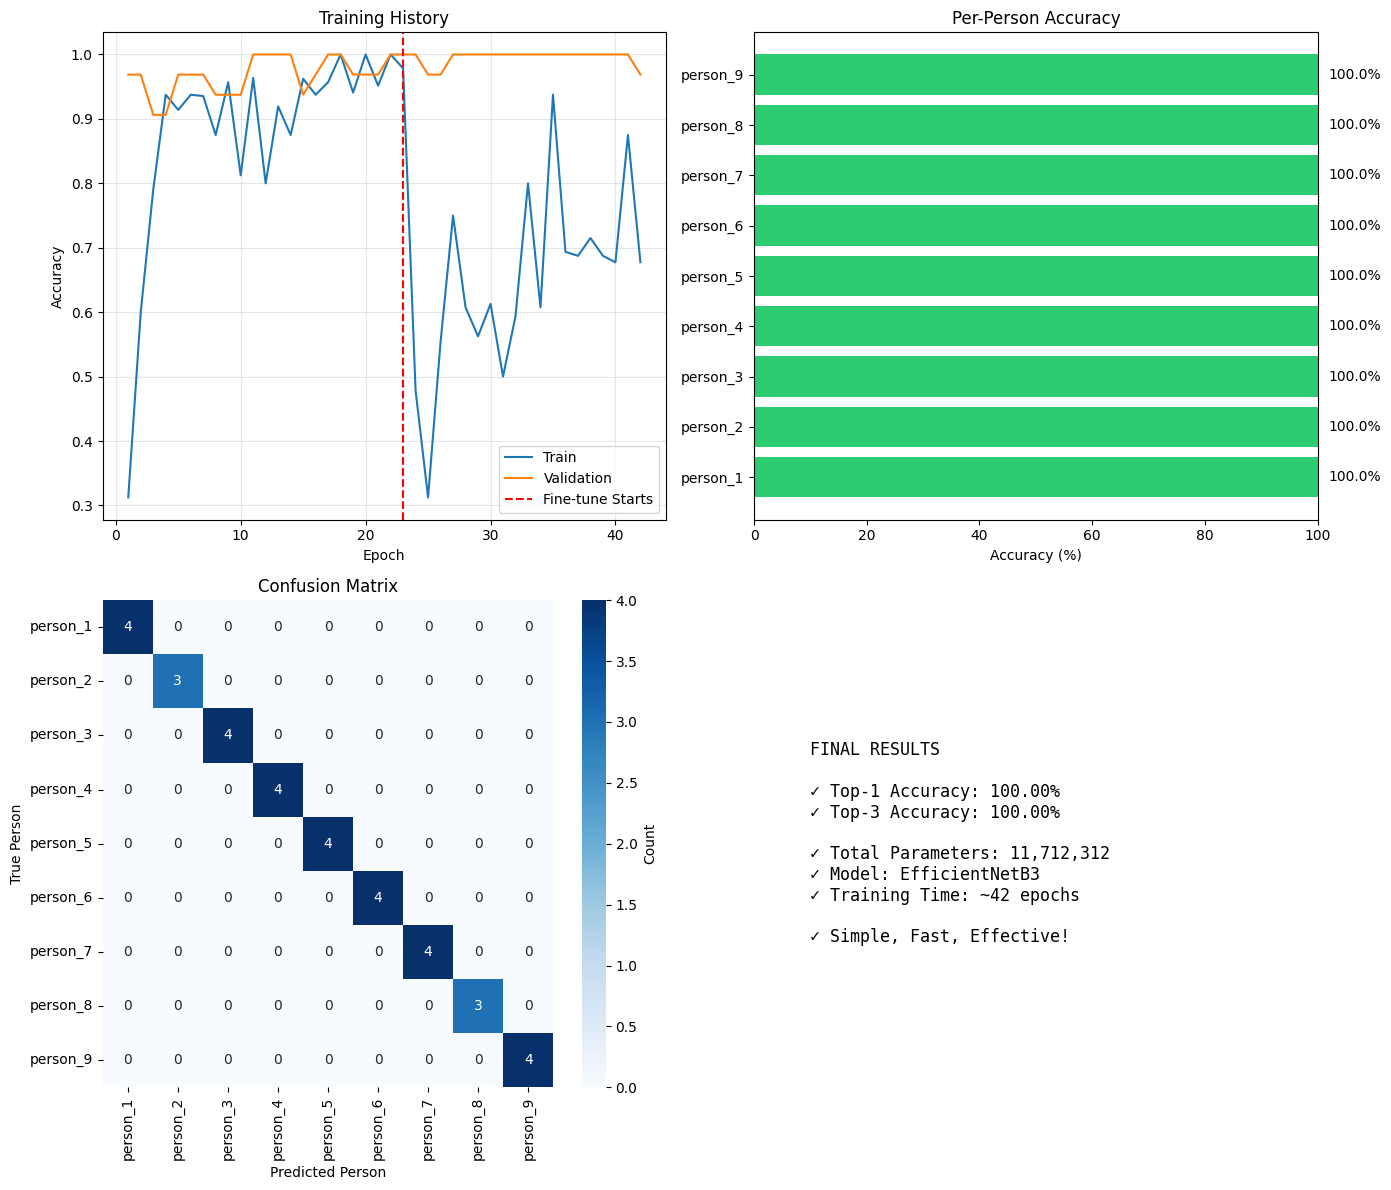

In [9]:
# ==============================================================================
# CELL 9: VISUALIZATION
# ==============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Training history
epochs_range = range(1, len(history1.history['accuracy']) + len(history2.history['accuracy']) + 1)
all_acc = list(history1.history['accuracy']) + list(history2.history['accuracy'])
all_val_acc = list(history1.history['val_accuracy']) + list(history2.history['val_accuracy'])

axes[0, 0].plot(epochs_range, all_acc, label='Train')
axes[0, 0].plot(epochs_range, all_val_acc, label='Validation')
axes[0, 0].axvline(x=len(history1.history['accuracy']), color='red', linestyle='--', label='Fine-tune Starts')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Training History')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Per-person accuracy
per_person_acc = [cm[i, i] / cm[i, :].sum() * 100 if cm[i, :].sum() > 0 else 0 for i in range(len(persons))]
axes[0, 1].barh(persons, per_person_acc, color='#2ecc71')
axes[0, 1].set_xlabel('Accuracy (%)')
axes[0, 1].set_title('Per-Person Accuracy')
axes[0, 1].set_xlim([0, 100])
for i, v in enumerate(per_person_acc):
    axes[0, 1].text(v + 2, i, f'{v:.1f}%', va='center')

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=persons, yticklabels=persons,
            ax=axes[1, 0], cbar_kws={'label': 'Count'})
axes[1, 0].set_ylabel('True Person')
axes[1, 0].set_xlabel('Predicted Person')
axes[1, 0].set_title('Confusion Matrix')

# Summary metrics
metrics_text = f"""
FINAL RESULTS

✓ Top-1 Accuracy: {accuracy*100:.2f}%
✓ Top-3 Accuracy: {top3_acc*100:.2f}%

✓ Total Parameters: {model.count_params():,}
✓ Model: EfficientNetB3
✓ Training Time: ~{len(history1.history['accuracy']) + len(history2.history['accuracy'])} epochs

✓ Simple, Fast, Effective!
"""
axes[1, 1].text(0.1, 0.5, metrics_text, fontsize=12, family='monospace',
                verticalalignment='center')
axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig('/content/person_id_results.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: person_id_results.png")
plt.show()

In [10]:
# ==============================================================================
# CELL 10: SAVE MODEL
# ==============================================================================

models_dir = '/content/drive/My Drive/signature_person_id_simple'
os.makedirs(models_dir, exist_ok=True)

# Save model
model.save(f'{models_dir}/person_id_model.h5')
print(f"✓ Saved model to: {models_dir}/person_id_model.h5")

# Save mappings
import pickle
with open(f'{models_dir}/person_mappings.pkl', 'wb') as f:
    pickle.dump({
        'person_to_label': person_to_label,
        'label_to_person': label_to_person,
        'persons_list': persons
    }, f)
print("✓ Saved person mappings")

# Save results
results = {
    'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    'accuracy': float(accuracy),
    'top3_accuracy': float(top3_acc),
    'per_person_accuracy': {persons[i]: float(per_person_acc[i]) for i in range(len(persons))},
    'model_name': 'EfficientNetB3',
    'total_parameters': int(model.count_params())
}

with open(f'{models_dir}/results.json', 'w') as f:
    json.dump(results, f, indent=2)
print("✓ Saved results")

# Copy visualization
import shutil
shutil.copy('/content/person_id_results.png', f'{models_dir}/person_id_results.png')


✓ Saved model to: /content/drive/My Drive/signature_person_id_simple/person_id_model.h5
✓ Saved person mappings
✓ Saved results


'/content/drive/My Drive/signature_person_id_simple/person_id_results.png'